# Bước 4: Giải thích bằng SHAP - Nhóm retail (14 đặc trưng, k=4)

SHAP (SHapley Additive exPlanations) được áp dụng qua mô hình surrogate Random Forest 200 cây, huấn luyện trên nhãn cluster K-Means++ k=4 từ nhóm retail (n=3.741).

## Phương pháp

Vì K-Means là **unsupervised**, SHAP cần một mô hình surrogate:

1. Huấn luyện **RandomForestClassifier (200 cây)** để dự đoán nhãn cluster k=4 của nhóm retail
2. Áp dụng **SHAP TreeExplainer** để phân tích đóng góp đặc trưng theo từng khách hàng
3. Tổng hợp giá trị SHAP để tạo ra bảng xếp hạng tầm quan trọng đặc trưng theo cluster

**Điều kiện tiên quyết:** Chạy `02_feature_engineering.ipynb` và `03_modeling.ipynb` trước.

Đầu vào:
- `data/processed/customer_features_retail_scaled.csv`: 3.741 x 14 đặc trưng đã chuẩn hoá
- `data/processed/cluster_assignments_retail_k4.csv`: nhãn cluster k=4

## Cài đặt

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import shap
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

ROOT = Path("../").resolve()
sys.path.insert(0, str(ROOT / "src"))

from notebook_io import rpath

RETAIL_SCALED_PATH = rpath("processed/customer_features_retail_scaled.csv")
CLUSTERS_PATH      = rpath("processed/cluster_assignments_retail_k4.csv")
FIG_DIR = ROOT / "figures" / "04_shap"
FIG_DIR.mkdir(parents=True, exist_ok=True)

CLUSTER_NAMES  = {
    0: 'C0 Seasonal Intensives',
    1: 'C1 High-Return Actives',
    2: 'C2 One-Time Explorers',
    3: 'C3 Occasional Loyalists',
}
# Wong CVD-safe palette: C0=orange, C1=blue, C2=bluish-green, C3=reddish-purple
from visual_style import CLUSTER_COLORS

## 1. Tải dữ liệu

In [2]:
df_retail = pd.read_csv(RETAIL_SCALED_PATH, index_col='CustomerID')
X_retail   = df_retail.values
feat_cols  = df_retail.columns.tolist()

clusters    = pd.read_csv(CLUSTERS_PATH).set_index('CustomerID')
labels      = clusters.reindex(df_retail.index)['cluster'].values.astype(int)

print(f"Retail cohort : {df_retail.shape[0]:,} customers × {df_retail.shape[1]} features")

Retail cohort : 3,741 customers × 14 features


## 2. Mô hình Surrogate

RandomForestClassifier 200 cây được huấn luyện **in-sample** trên toàn bộ 3.741 khách hàng retail.
Độ chính xác in-sample = 1,000 chỉ xác nhận rằng RF có thể tái tạo lại các nhãn K-Means trên dữ liệu huấn luyện.
Cross-validation và độ nhạy seed được báo cáo riêng.

SHAP TreeExplainer sau đó phân tích dự đoán của mỗi khách hàng thành đóng góp theo từng đặc trưng.

In [3]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_retail, labels)
acc = rf.score(X_retail, labels)
print(f"Surrogate RF in-sample accuracy: {acc:.4f}")

explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_retail)

# Normalise SHAP output: newer SHAP returns 3D (n_samples, n_features, n_classes);
# older API returns list of (n_samples, n_features). Standardise to list of 2D arrays.
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values = [shap_values[:, :, c] for c in range(shap_values.shape[2])]

print(f"SHAP computed: {len(shap_values)} classes × {shap_values[0].shape}")

Surrogate RF in-sample accuracy: 1.0000


SHAP computed: 4 classes × (3741, 14)


In [4]:
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score

majority_baseline = pd.Series(labels).value_counts(normalize=True).max()
print(f"Majority-class baseline accuracy : {majority_baseline:.4f}  (C2 One-Time Explorers, n=1,257)")

print("\nIn-sample classification report (all 3,741 customers):")
print(classification_report(labels, rf.predict(X_retail),
                             target_names=list(CLUSTER_NAMES.values())))

cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_retail, labels, cv=cv_folds, scoring='accuracy')
print(f"Stratified 5-fold CV accuracy : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Fold scores                   : {[f'{s:.4f}' for s in cv_scores]}")

Majority-class baseline accuracy : 0.3360  (C2 One-Time Explorers, n=1,257)

In-sample classification report (all 3,741 customers):
                         precision    recall  f1-score   support

 C0 Seasonal Intensives       1.00      1.00      1.00       330
 C1 High-Return Actives       1.00      1.00      1.00      1107
  C2 One-Time Explorers       1.00      1.00      1.00      1257
C3 Occasional Loyalists       1.00      1.00      1.00      1047

               accuracy                           1.00      3741
              macro avg       1.00      1.00      1.00      3741
           weighted avg       1.00      1.00      1.00      3741



Stratified 5-fold CV accuracy : 0.9904 ± 0.0023
Fold scores                   : ['0.9880', '0.9893', '0.9893', '0.9906', '0.9947']


## 3. Tầm quan trọng đặc trưng toàn cục

Tổng |SHAP| cộng dồn qua tất cả khách hàng và 4 class, chuẩn hoá về tổng = 1.
Đây là độ lớn quy kết tương đối của mô hình surrogate, không phải tầm quan trọng nhân quả.

In [5]:
global_abs = np.sum([np.abs(sv) for sv in shap_values], axis=0)  # (n_customers, n_features)
mean_abs   = global_abs.mean(axis=0)                              # (n_features,)
mean_abs_norm = mean_abs / mean_abs.sum()

feat_importance = pd.Series(mean_abs_norm, index=feat_cols).sort_values(ascending=False)
print("Global feature importance (total |SHAP|, normalised):")
for i, (feat, val) in enumerate(feat_importance.items()):
    print(f"  {i+1:2d}. {feat:<28} {val:.4f}")

print(f"\nTop 5 features account for {feat_importance.head(5).sum():.1%} of discriminating power.")

Global feature importance (total |SHAP|, normalised):
   1. ReturnRate                   0.2747
   2. QuarterConcentration         0.2101
   3. BasketSizeCV                 0.1838
   4. RepeatSKUFraction            0.1122
   5. MonthlyOrderRate             0.0996
   6. InterPurchaseCV              0.0571
   7. Recency                      0.0115
   8. AOV                          0.0111
   9. SKU_HHI                      0.0109
  10. SpendAcceleration            0.0087
  11. BulkLineRate                 0.0067
  12. MedianBasketQty              0.0050
  13. QuantityCV                   0.0046
  14. PriceCV                      0.0040

Top 5 features account for 88.0% of discriminating power.


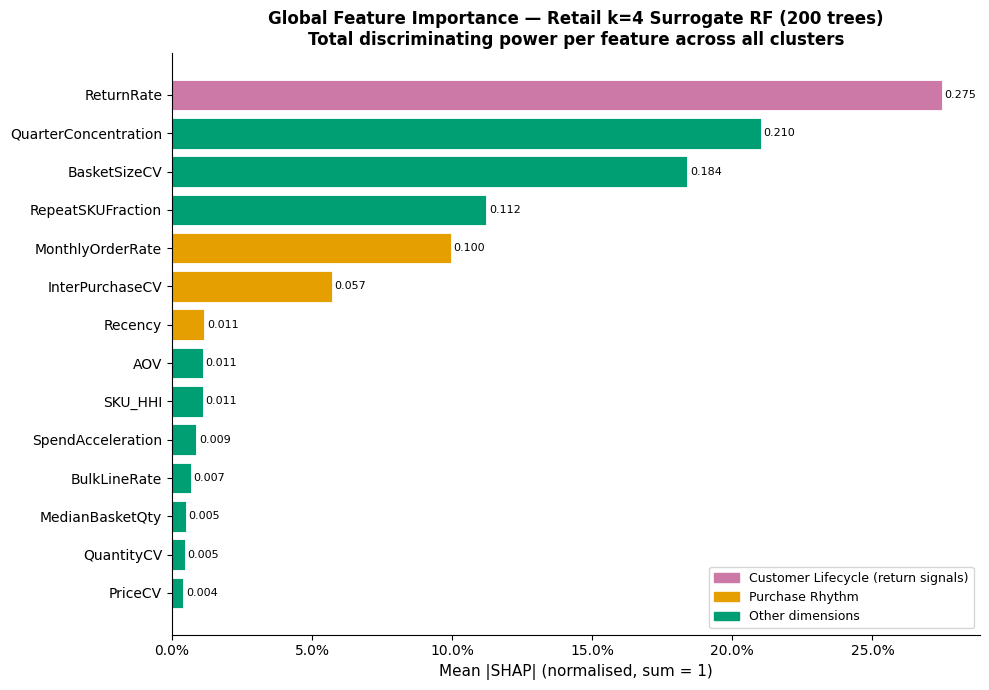

Saved: /Users/thaihanguyen/Desktop/03_work/99_personal_projects/17_data_science_project/advanced_customer_segmentation/figures/04_shap/shap_importance_retail_k4.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 7))

order = feat_importance.index.tolist()[::-1]
vals  = feat_importance[order].values
# Wong-compatible feature category colors
colors = ['#CC79A7' if f in ('ReturnRate', 'ReturnValueRate') else
          '#E69F00' if f in ('ActiveSpanDays', 'MonthlyOrderRate', 'Recency', 'InterPurchaseCV') else
          '#009E73' for f in order]

bars = ax.barh(order, vals, color=colors, edgecolor='white', linewidth=0.6)
ax.set_xlabel('Mean |SHAP| (normalised, sum = 1)', fontsize=11)
ax.set_title('Global Feature Importance — Retail k=4 Surrogate RF (200 trees)\n'
             'Total discriminating power per feature across all clusters', fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))

for bar, val in zip(bars, vals):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#CC79A7', label='Customer Lifecycle (return signals)'),
    Patch(color='#E69F00', label='Purchase Rhythm'),
    Patch(color='#009E73', label='Other dimensions'),
], fontsize=9, loc='lower right')

ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_importance_retail_k4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', FIG_DIR / 'shap_importance_retail_k4.png')

## 4. Bảng hướng SHAP - Trung bình SHAP có dấu theo cluster

Với mỗi cluster, giá trị SHAP trung bình có dấu theo từng đặc trưng cho thấy **hướng** mà mỗi đặc trưng đẩy khách hàng vào (dương) hoặc ra khỏi (âm) cluster đó.

Lưới 2x2 - một subplot cho mỗi cluster.

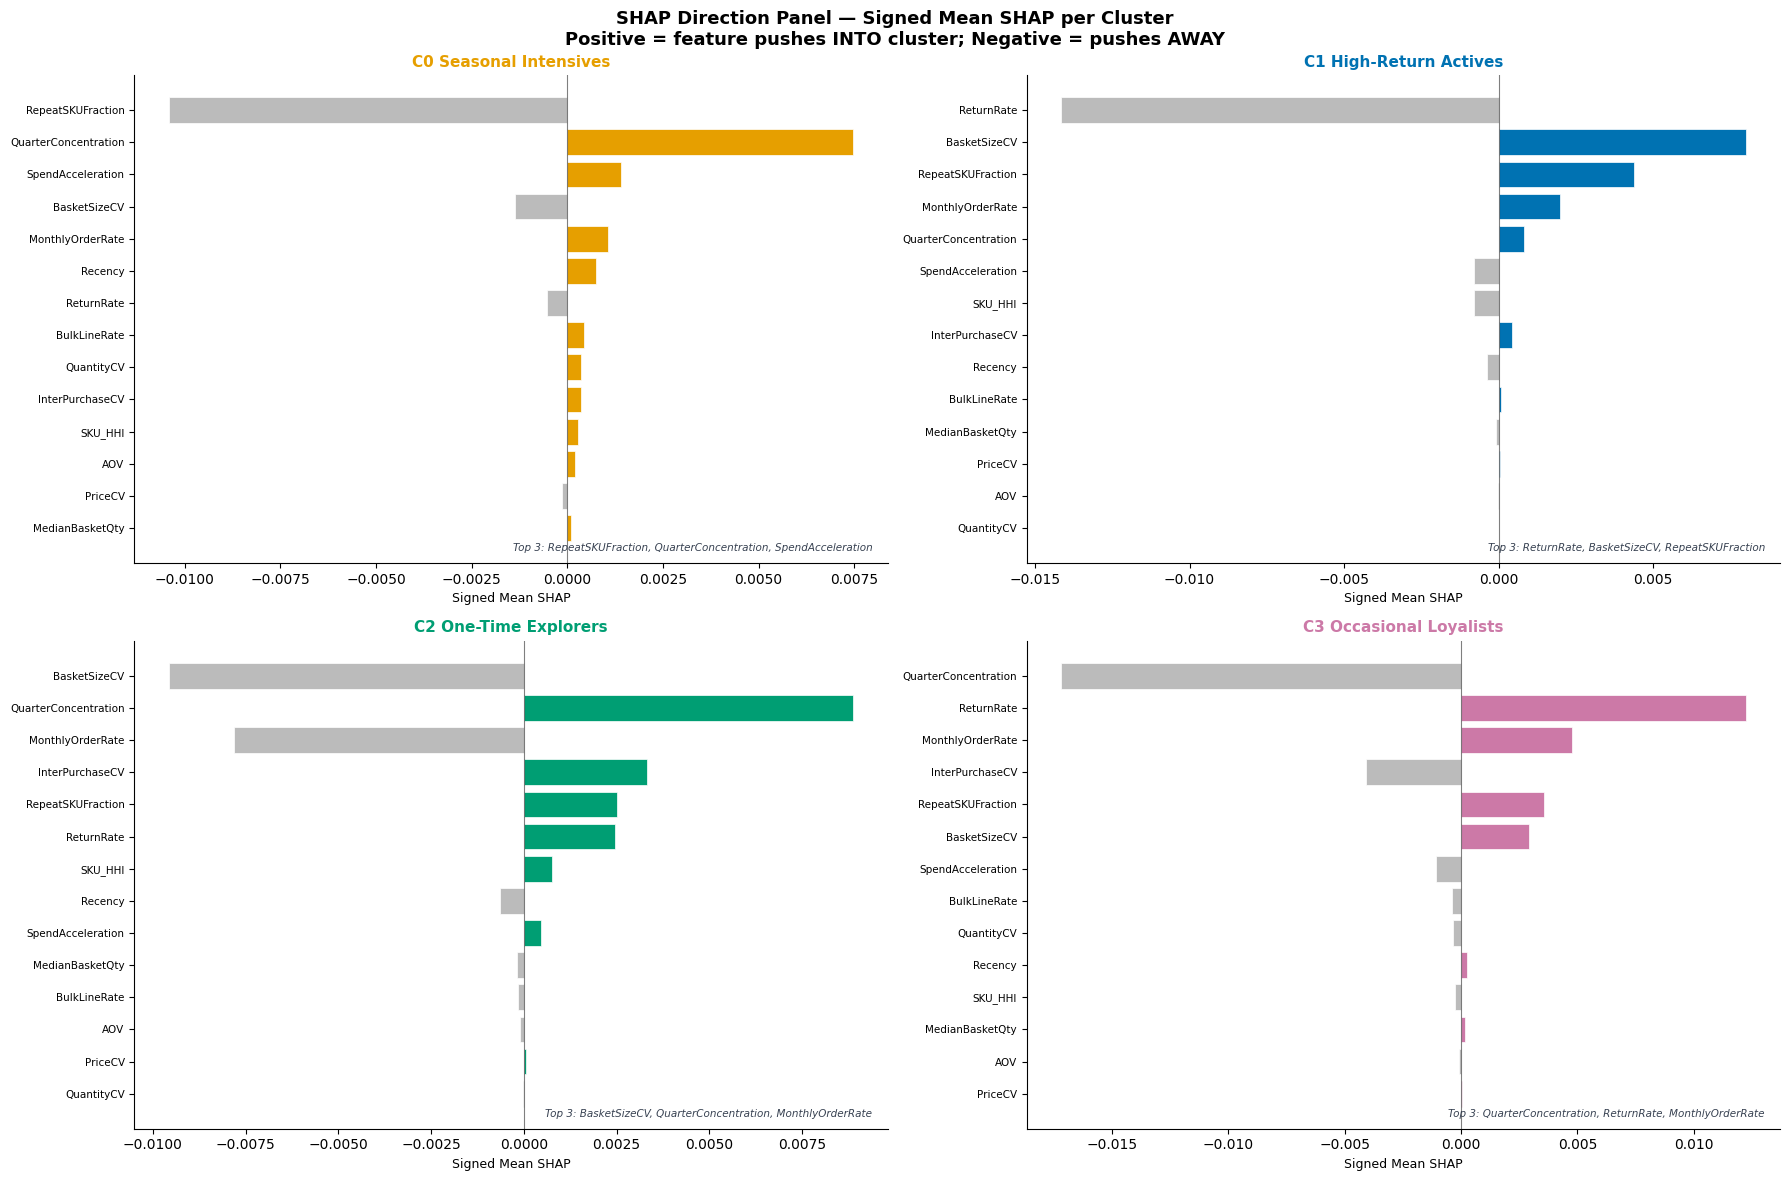

Saved: /Users/thaihanguyen/Desktop/03_work/99_personal_projects/17_data_science_project/advanced_customer_segmentation/figures/04_shap/shap_direction_retail_k4.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('SHAP Direction Panel — Signed Mean SHAP per Cluster\n'
             'Positive = feature pushes INTO cluster; Negative = pushes AWAY',
             fontsize=13, fontweight='bold')

for ax, c in zip(axes.flat, range(4)):
    sv          = shap_values[c]                      # (n, 18)
    mean_signed = sv.mean(axis=0)                     # (18,)
    order       = np.argsort(np.abs(mean_signed))
    feats_ord   = [feat_cols[i] for i in order]
    vals_ord    = mean_signed[order]
    # Wong-compatible directional colors: cluster color for positive, muted for negative
    bar_colors  = [CLUSTER_COLORS[c] if v > 0 else '#BBBBBB' for v in vals_ord]

    ax.barh(feats_ord, vals_ord, color=bar_colors, edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='black', lw=0.8, alpha=0.5)
    ax.set_title(CLUSTER_NAMES[c], fontsize=11, fontweight='bold', color=CLUSTER_COLORS[c])
    ax.set_xlabel('Signed Mean SHAP', fontsize=9)
    ax.tick_params(axis='y', labelsize=7.5)
    ax.spines[['top', 'right']].set_visible(False)

    top3 = pd.Series(mean_signed, index=feat_cols).abs().nlargest(3).index.tolist()
    ax.text(0.98, 0.02, 'Top 3: ' + ', '.join(top3),
            transform=ax.transAxes, ha='right', va='bottom', fontsize=7.5,
            style='italic', color='#374151')

plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_direction_retail_k4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', FIG_DIR / 'shap_direction_retail_k4.png')

## 5. Bảng Beeswarm SHAP - Phân phối theo từng khách hàng

**Cách đọc:**
- **Trục Y**: Các đặc trưng xếp hạng theo |SHAP| trung bình của cluster đó (quan trọng nhất ở trên)
- **Trục X**: Giá trị SHAP, dương đẩy vào cluster; âm đẩy ra khỏi cluster
- **Màu sắc**: Giá trị đặc trưng, đỏ = cao (z-score), xanh = thấp (z-score)
- **Mỗi chấm**: Một khách hàng

Chấm đỏ ở phía dương nghĩa là "giá trị đặc trưng cao đẩy khách hàng này vào cluster đó".

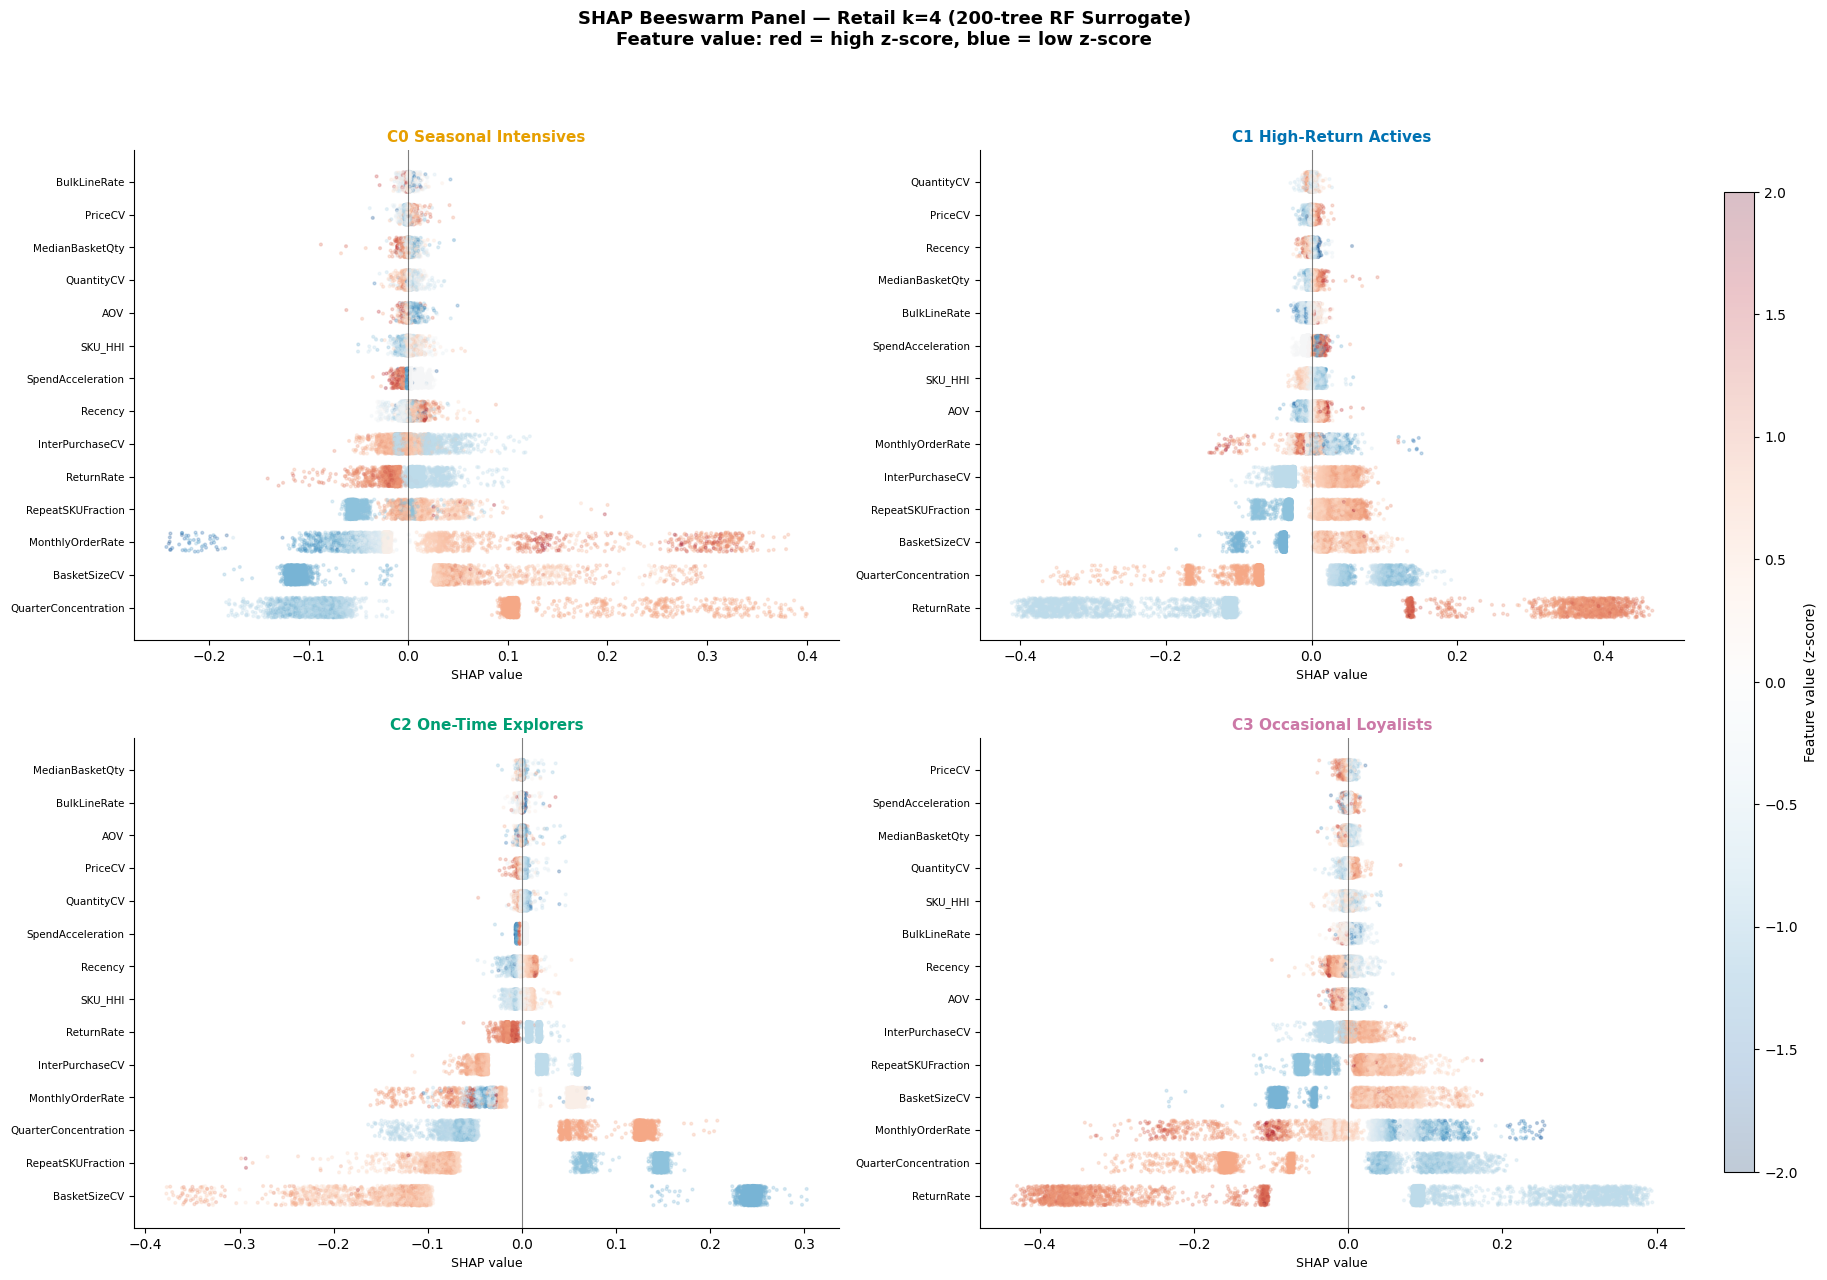

Saved: /Users/thaihanguyen/Desktop/03_work/99_personal_projects/17_data_science_project/advanced_customer_segmentation/figures/04_shap/shap_beeswarm_retail_k4.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('SHAP Beeswarm Panel — Retail k=4 (200-tree RF Surrogate)\n'
             'Feature value: red = high z-score, blue = low z-score',
             fontsize=13, fontweight='bold')

for ax, c in zip(axes.flat, range(4)):
    sv        = shap_values[c]                        # (n, 18)
    mean_abs  = np.abs(sv).mean(axis=0)
    order     = np.argsort(mean_abs)[::-1][:15]       # top 15 features by |SHAP|
    sv_top    = sv[:, order]
    feat_top  = [feat_cols[i] for i in order]
    X_top     = X_retail[:, order]

    cluster_mask = (labels == c)

    for j, (feat, shap_col, feat_col) in enumerate(zip(feat_top, sv_top.T, X_top.T)):
        y_jitter = j + np.random.default_rng(42).uniform(-0.3, 0.3, len(shap_col))
        sc = ax.scatter(shap_col, y_jitter, c=feat_col, cmap='RdBu_r',
                        alpha=0.25, s=4, vmin=-2, vmax=2, rasterized=True)

    ax.set_yticks(range(len(feat_top)))
    ax.set_yticklabels(feat_top, fontsize=7.5)
    ax.axvline(0, color='black', lw=0.8, alpha=0.5)
    ax.set_title(CLUSTER_NAMES[c], fontsize=11, fontweight='bold', color=CLUSTER_COLORS[c])
    ax.set_xlabel('SHAP value', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
plt.colorbar(sc, cax=cbar_ax, label='Feature value (z-score)')
plt.subplots_adjust(right=0.90)
plt.savefig(FIG_DIR / 'shap_beeswarm_retail_k4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', FIG_DIR / 'shap_beeswarm_retail_k4.png')

## 6. Diễn giải SHAP theo từng cluster

### C0 - Seasonal Intensives (n=330, 8,8%)
`MonthlyOrderRate` và `QuarterConcentration` là hai yếu tố chính: khách hàng mua dồn dập nhưng tập trung vào một mùa cao điểm (Q4). SHAP của `ReturnRate` gần bằng 0 (C0 không được định nghĩa bởi hành vi hoàn trả).

### C1 - High-Return Actives (n=1.107, 29,6%)
`ReturnRate` là yếu tố áp đảo (|SHAP| trung bình khoảng 0,38, vượt xa các đặc trưng còn lại). Hoạt động mua hàng trải rộng qua các quý (QuarterConcentration thấp), cho thấy hành vi hoàn trả mang tính hệ thống chứ không phải theo mùa. Đây là nhóm có LTV cao nhất, nhưng RFM không mã hoá tỉ lệ hoàn trả nên bị phân loại sai là "Champions".

### C2 - One-Time Explorers (n=1.257, 33,6%)
`BasketSizeCV` và `RepeatSKUFraction` đều thấp, cho thấy chỉ một đợt mua hàng duy nhất, không có SKU lặp lại. `QuarterConcentration` cao xác nhận toàn bộ hoạt động dồn vào một quý (hệ quả của việc mua một lần). RFM gán nhầm nhóm này là "At-Risk" và kích hoạt chiến dịch chào lại không cần thiết.

### C3 - Occasional Loyalists (n=1.047, 28,0%)
Được định nghĩa chủ yếu bởi sự vắng mặt của hoàn trả: `ReturnRate` gần bằng 0 là tín hiệu phân tách C3 khỏi C1. `MonthlyOrderRate` thấp hơn nhóm mùa vụ; hoạt động phân bổ đều qua các quý. RFM gán nhầm là "Need Attention" (tần suất thấp), thực tế đây là nhóm ổn định với chi phí hỗ trợ thấp.

## 7. |SHAP| trung bình theo cluster - Xếp hạng đặc trưng cho từng phân khúc

Tầm quan trọng toàn cục (mục 3) gộp chung 4 cluster và phản ánh đặc trưng nào tách biệt **bất kỳ** cluster nào so với phần còn lại. Mục này tính |SHAP| trung bình giới hạn trong **khách hàng của cluster đó**, trả lời câu hỏi "đặc trưng nào ảnh hưởng nhiều nhất đến việc gán khách hàng C0 vào C0?"

Điều này giải quyết sự mơ hồ giữa xếp hạng toàn cục (ví dụ `BasketSizeCV` xếp hạng 3 toàn cục vì chi phối khả năng tách C2) và xếp hạng theo từng cluster.

In [9]:
print("PER-CLUSTER MEAN |SHAP| — Top 6 features per cluster")
print("(mean |SHAP| for class c, restricted to customers in each cluster)")

per_cluster_importance = {}

for c in range(4):
    mask = (labels == c)
    # SHAP values for class c, averaged over cluster c's own customers only
    mean_abs_c = np.abs(shap_values[c][mask]).mean(axis=0)
    feat_imp_c = pd.Series(mean_abs_c, index=feat_cols).sort_values(ascending=False)
    per_cluster_importance[c] = feat_imp_c

    print(f"\n{CLUSTER_NAMES[c]} (n={mask.sum():,}):")
    print(f"  {'Rank':<5} {'Feature':<28} {'Mean |SHAP|':>12}")
    print(f"  {'-'*47}")
    for i, (feat, val) in enumerate(feat_imp_c.head(6).items()):
        marker = " ◀ leads" if i == 0 else ""
        print(f"  {i+1:<5} {feat:<28} {val:>10.4f}{marker}")

print("\n" + "=" * 80)
print("SUMMARY — Primary driver per cluster (per-cluster |SHAP|, not global ranking):")
for c in range(4):
    top_feat = per_cluster_importance[c].index[0]
    top_val  = per_cluster_importance[c].iloc[0]
    print(f"  {CLUSTER_NAMES[c]}: {top_feat} ({top_val:.4f})")

PER-CLUSTER MEAN |SHAP| — Top 6 features per cluster
(mean |SHAP| for class c, restricted to customers in each cluster)

C0 Seasonal Intensives (n=330):
  Rank  Feature                       Mean |SHAP|
  -----------------------------------------------
  1     MonthlyOrderRate                 0.2768 ◀ leads
  2     QuarterConcentration             0.2650
  3     BasketSizeCV                     0.1647
  4     RepeatSKUFraction                0.0426
  5     InterPurchaseCV                  0.0402
  6     ReturnRate                       0.0360

C1 High-Return Actives (n=1,107):
  Rank  Feature                       Mean |SHAP|
  -----------------------------------------------
  1     ReturnRate                       0.3823 ◀ leads
  2     QuarterConcentration             0.1113
  3     BasketSizeCV                     0.0618
  4     RepeatSKUFraction                0.0491
  5     InterPurchaseCV                  0.0467
  6     MonthlyOrderRate                 0.0239

C2 One-Time Explore

## Tổng kết

**Độ chính xác surrogate RF = 1,000 (in-sample) / 0,9904 ± 0,0023 (5-fold OOF)**: chỉ số fidelity của surrogate, không phải bằng chứng rằng k=4 là cấu trúc duy nhất đúng.

**Các đặc trưng toàn cục hàng đầu** (theo tổng |SHAP|, chuẩn hoá):
- `ReturnRate` khoảng 27% và `QuarterConcentration` khoảng 21%: nhóm Customer Lifecycle dẫn đầu
- `BasketSizeCV` khoảng 18%: cấu trúc giỏ hàng phân tách C2 (giỏ phẳng, một đợt mua) khỏi phần còn lại
- `RepeatSKUFraction` khoảng 11% và `MonthlyOrderRate` khoảng 10%: hành vi lặp lại và nhịp độ mua hàng

**Kết quả SHAP chính theo cluster** (đặc trưng dẫn đầu theo |SHAP| trung bình của cluster):
| Cluster | Tín hiệu SHAP đặc trưng |
|---------|------------------------|
| C0 Seasonal Intensives | MonthlyOrderRate cao, QuarterConcentration cao (thường xuyên, một đỉnh mùa) |
| C1 High-Return Actives | ReturnRate cao (chiếm gần 40% độ quy kết của cluster; không được mã hoá bởi RFM) |
| C2 One-Time Explorers | BasketSizeCV thấp, RepeatSKUFraction thấp (một đợt mua, không lặp lại) |
| C3 Occasional Loyalists | ReturnRate gần 0, MonthlyOrderRate thấp (phân tách C3 khỏi C1) |

**Các hình đã lưu:**
- `figures/04_shap/shap_importance_retail_k4.png`
- `figures/04_shap/shap_direction_retail_k4.png`
- `figures/04_shap/shap_beeswarm_retail_k4.png`